In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as const

from accomp import class_Molecule
from accomp import class_Star
from accomp import class_Disk

Create an object of class Star. This is often the first step because the host star sets the reference composition and determines disk properties


In [2]:
st = class_Star.Star()
disk = class_Disk.Disk(star_object=st)

Let us replicate the models in Chachan et al. 2023. Specify the composition of solids and gas first.

In [3]:
scenarios = np.array(['Within soot line', 'Between soot line and H$_2$O snowline', 'Just within H$_2$O snowline', 'Just beyond H$_2$O snowline', 'Between H$_2$O and CO snowlines', 'Just within CO snowline', 'Just beyond CO snowline', 'Beyond CO snowline'])

O_comp_solids = np.array([0.25, 0.25, 0.25, 10.73, 0.73, 0.73, 6.5, 1.])
O_comp_gas = np.array([0.75, 0.75, 10.75, 0.27, 0.27, 5.77, 0., 0.])

C_comp_solids = np.array([0., 0.12, 0.12, 0.12, 0.12, 0.12, 11., 1.])
C_comp_gas = np.array([1., 0.88, 0.88, 0.88, 0.88, 10.88, 0., 0.]) 

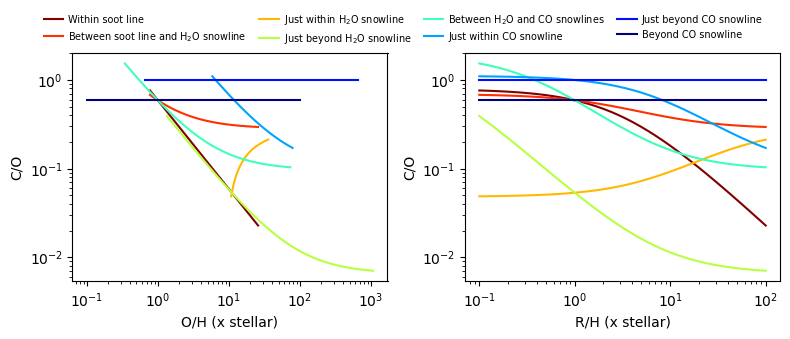

In [4]:
Si_to_H_vary = np.logspace(-1, 2., 40)

plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.jet_r(np.linspace(0,1,len(scenarios))))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axs = plt.subplots(ncols=2, figsize=(8, 3.5))

for s, scen in enumerate(scenarios):
    solid_comp, gas_comp = {}, {}
    solid_comp['O'], gas_comp['O'] = O_comp_solids[s], O_comp_gas[s]
    solid_comp['C'], gas_comp['C'] = C_comp_solids[s], C_comp_gas[s]

    solid_comp['Si'], gas_comp['Si'] = 1., 0.

    predicted_comp = disk.assemble_planet(Si_to_H_vary, solid_comp, gas_comp)

    axs[0].loglog(predicted_comp['O'], predicted_comp['C'] / predicted_comp['O'] * st.CtoO, label=scen)
    axs[1].loglog(Si_to_H_vary, predicted_comp['C'] / predicted_comp['O'] * st.CtoO)

#axs[0].legend(fontsize=8)
axs[0].set_xlabel('O/H (x stellar)')
axs[0].set_ylabel('C/O')

axs[0].legend(fontsize=7, ncol=4, bbox_to_anchor=(-0.1, 1.02, 2.3, .102), loc='lower left', mode="expand", borderaxespad=0., handletextpad=0.5, borderpad=0.3, frameon=False)

axs[1].set_xlabel('R/H (x stellar)')
axs[1].set_ylabel('C/O')

fig.tight_layout()
#plt.savefig('formation-composition-links.pdf', bbox_inches='tight')

You can also use the default disk composition that we have set up in the new repository instead to make such a plot.

In [5]:
mol_dict = class_Molecule.MoleculeDict(st)
mol_dict.set_default_composition()

disk.set_temp_struct()

Putting remaining element fraction for C in refractory
Putting remaining element fraction for O in refractory
Putting remaining element fraction for S in refractory


In [6]:
Tcond_dict = mol_dict.get_mol_Tcond()
Tcond_dict

{'Al': 1600.0,
 'Ca': 1600.0,
 'Si': 1350.0,
 'Mg': 1350.0,
 'Fe': 1350.0,
 'Ni': 1350.0,
 'O_refractory': 1350.0,
 'Na': 1000.0,
 'S_refactory': 700.0,
 'C_refactory': 300.0,
 'NH4SH': 200.0,
 'NH4': 200.0,
 'H2O': 170.0,
 'NH3': 110.0,
 'CO2': 70.0,
 'H2S': 60.0,
 'CO': 30.0,
 'N2': 25.0,
 'Ne': 25.0,
 'Ar': 25.0}

Putting remaining element fraction for C in refractory
Putting remaining element fraction for O in refractory
Putting remaining element fraction for S in refractory
Putting remaining element fraction for C in refractory
Putting remaining element fraction for O in refractory
Putting remaining element fraction for S in refractory


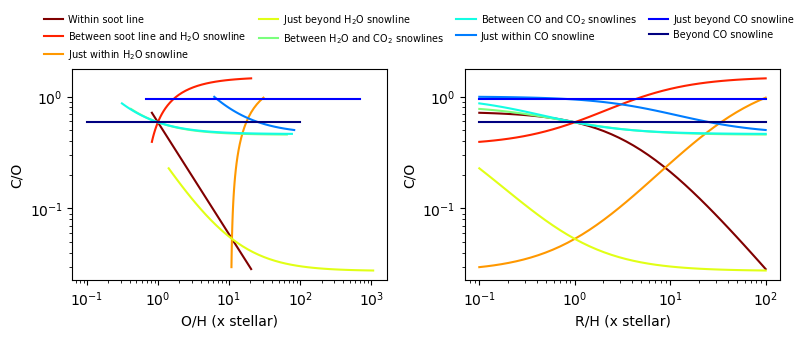

In [7]:
Si_to_H_vary = np.logspace(-1., 2., 40)

T_arr = np.array([400., 200., 180., 160., 100., 50., 35., 25., 25.])
lbls_arr = np.array(['Within soot line', 'Between soot line and H$_2$O snowline', 'Just within H$_2$O snowline', 'Just beyond H$_2$O snowline', 'Between H$_2$O and CO$_2$ snowlines', 'Between CO and CO$_2$ snowlines', 'Just within CO snowline', 'Just beyond CO snowline', 'Beyond CO snowline'])


plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.jet_r(np.linspace(0,1,len(lbls_arr))))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

enriched = np.array([None, None, 'H2O', 'H2O', None, None, 'CO', 'CO', None])
enrichment = 10.

mol_dict_H2O_enriched = class_Molecule.MoleculeDict(st)
mol_dict_H2O_enriched.set_default_composition()
h2o_enriched = class_Molecule.EnrichedMolecule('H2O', 170.)
h2o_enriched.set_elem_fraction(st, 'O', enrichment)
mol_dict_H2O_enriched.molecule_dict['H2O_enrich'] = h2o_enriched

mol_dict_CO_enriched = class_Molecule.MoleculeDict(st)
mol_dict_CO_enriched.set_default_composition()
co_enriched = class_Molecule.EnrichedMolecule('CO', 30.)
co_enriched.set_elem_fraction(st, 'C', enrichment)
mol_dict_CO_enriched.molecule_dict['CO_enrich'] = co_enriched

fig, axs = plt.subplots(ncols=2, figsize=(8, 3.5))

for t, temp in enumerate(T_arr):
    if enriched[t] == 'H2O':
        solid_comp, gas_comp = disk.get_solid_gas_composition(mol_dict_H2O_enriched, temp=temp)
    elif enriched[t] == 'CO':
        solid_comp, gas_comp = disk.get_solid_gas_composition(mol_dict_CO_enriched, temp=temp)
    else:
        solid_comp, gas_comp = disk.get_solid_gas_composition(mol_dict, temp=temp)
    predicted_comp = disk.assemble_planet(Si_to_H_vary, solid_comp, gas_comp)

    axs[0].loglog(predicted_comp['O'], predicted_comp['C'] / predicted_comp['O'] * st.CtoO, label=lbls_arr[t])
    axs[1].loglog(Si_to_H_vary, predicted_comp['C'] / predicted_comp['O'] * st.CtoO)

#axs[0].legend(fontsize=8)
axs[0].set_xlabel('O/H (x stellar)')
axs[0].set_ylabel('C/O')

axs[0].legend(fontsize=7, ncol=4, bbox_to_anchor=(-0.1, 1.02, 2.4, .102), loc='lower left', mode="expand", borderaxespad=0., handletextpad=0.5, borderpad=0.3, frameon=False)

axs[1].set_xlabel('R/H (x stellar)')
axs[1].set_ylabel('C/O')

fig.tight_layout()
#plt.savefig('formation-composition-links.pdf', bbox_inches='tight')